In [1]:
import sys
import subprocess

subprocess.run(f"{sys.executable} -m venv myenv", shell=True, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
subprocess.run("myenv/bin/pip install -r req.txt", shell=True, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

CompletedProcess(args='myenv/bin/pip install -r req.txt', returncode=0)

In [2]:
# Задание: https://drive.google.com/drive/folders/1gHhM38ryprwe-XPUmKzDgKYSr3cpE35z
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np

**№2.1**

Пункт 1

In [3]:
# Датасет 
df = pd.read_csv("retail_sales_mock_data.csv")
df.head()

,Date,SalesAmount,Promotion,HolidayMonth
0,2020-01-01,12248,0,0
1,2020-02-01,13011,0,0
2,2020-03-01,12722,0,0
3,2020-04-01,14030,1,0
4,2020-05-01,7783,0,0


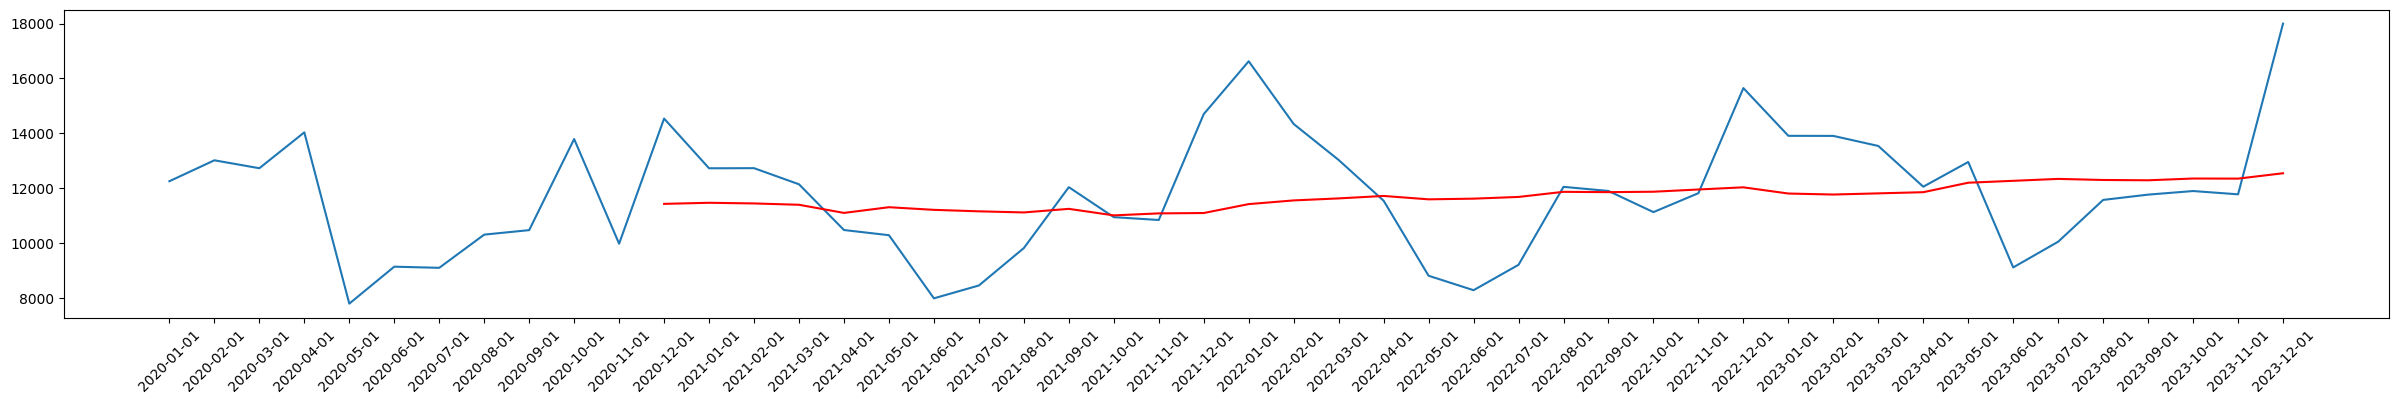

In [4]:
# Сортируем по датам 
x, y = df["Date"], df["SalesAmount"]
moving_average = df['SalesAmount'].rolling(window=12).mean()
# Видно, что пик продаж приходится на декабрь
plt.figure(figsize=(30, 4))
plt.xticks(rotation=45)
plt.plot(x, y)
plt.plot(x, moving_average, color="r")
plt.show()

Пункт 2

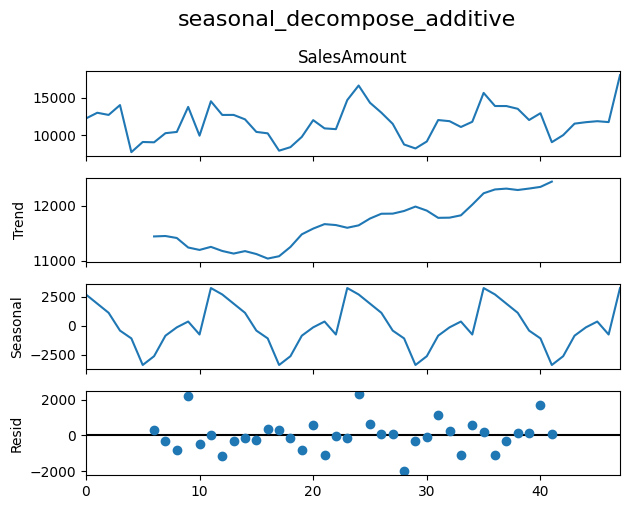

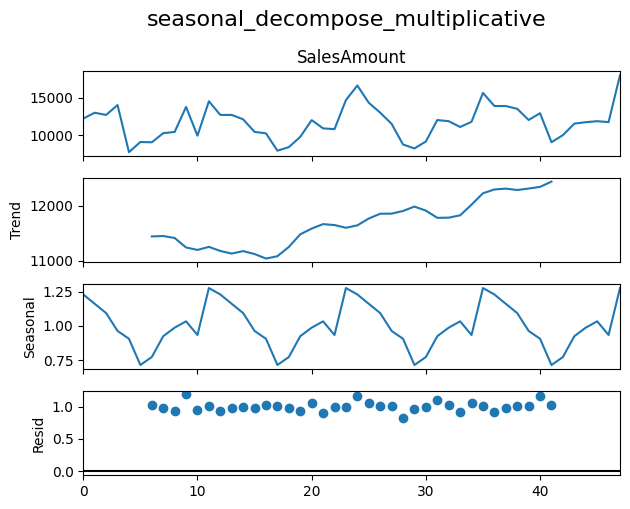

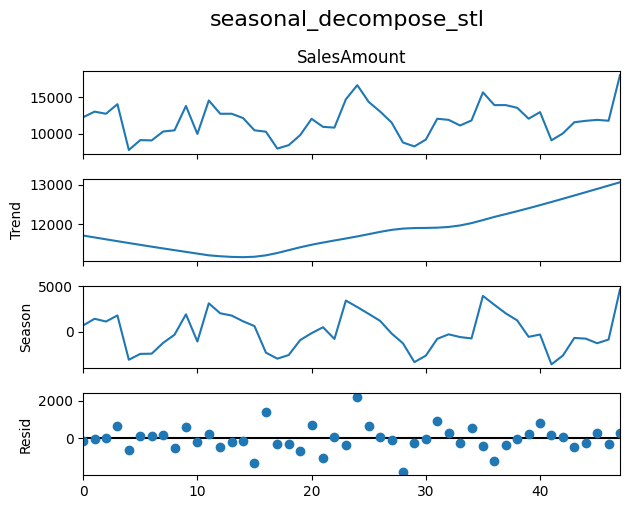

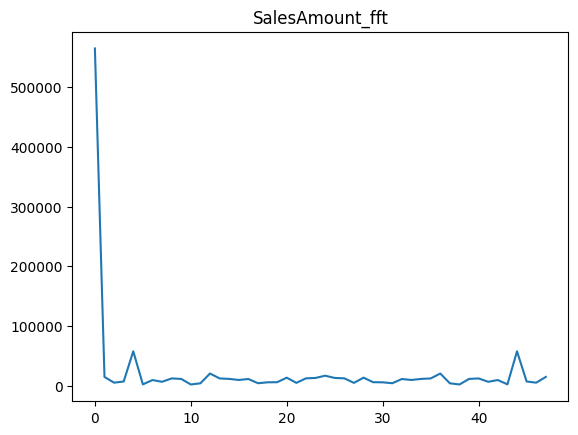

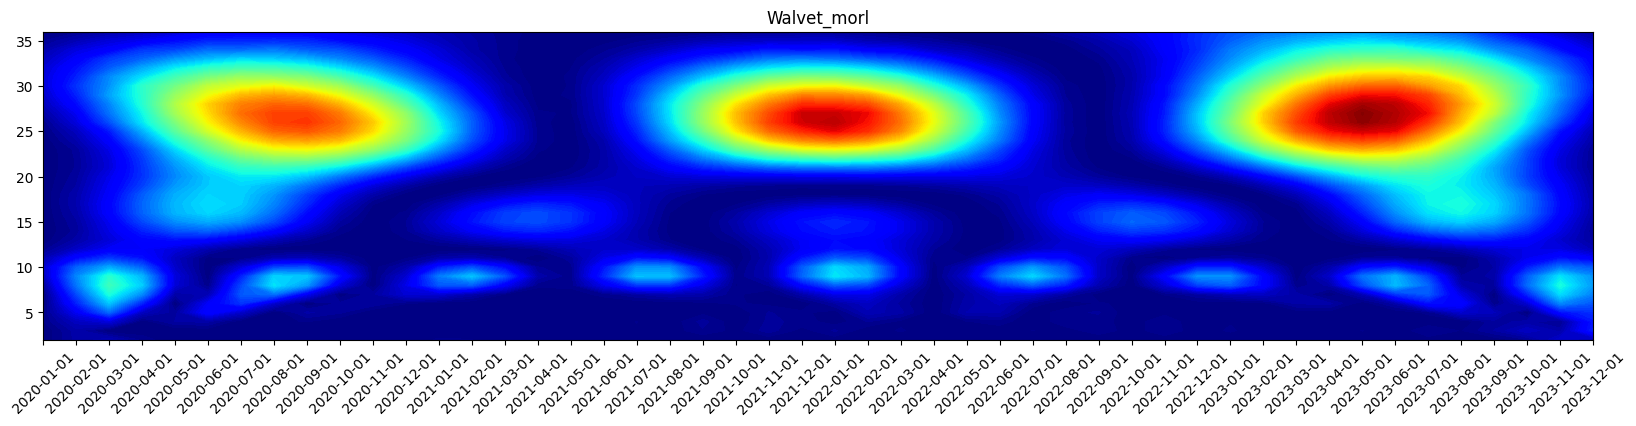

In [5]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.seasonal import STL
import pywt

# аддитивная/мультипликативная
for model in ["additive", "multiplicative"]:
    sd = seasonal_decompose(df["SalesAmount"], period=12, model=model)
    sd.plot()
    plt.tight_layout()
    plt.suptitle(f"seasonal_decompose_{model}", fontsize=16, y=1.05, x=0.55)
    plt.show()

# stl декомпозиция
stl = STL(df["SalesAmount"], period=12).fit()
stl.plot()
plt.tight_layout()
plt.suptitle(f"seasonal_decompose_stl", fontsize=16, y=1.05, x=0.55)
plt.show()

# FFT
val = df["SalesAmount"].values
val_fft = np.fft.fft(val)
plt.plot(np.abs(val_fft)) 
plt.title("SalesAmount_fft")
plt.show()


# вейвлет-анализ morl
period = np.arange(2, 37)
coef, _ = pywt.cwt(val, period, "morl")
power = np.abs(coef) * np.abs(coef)
plt.figure(figsize=(20, 4))
plt.contourf(df.Date, period, power, levels=100, cmap='jet')
plt.title("Walvet_morl")
plt.xticks(rotation=45)
plt.show()

1. **Additive:**
    - линия тренда ползет вверх, что говорит о росте продаж; 
    - продажи, с небольшими просадками, растут, начиная, приблизительно, с конца первой трети года, достигают пика в декабре, после чего начинают снижаться;
    - модель "плохо" справилась с ростом продаж в декабре.
2. **Multiplicative:**
    - модель показала идентичный результат, но остаток минимизирован. Значит, модель справилась с масштабированием, вызванным декабрьским ростом продаж.
3. **STL:**
    - тренд подтверждает устойчивый рост продаж;
    - подтверждает то, что мультипликативная модель справилась лучше, сезонный эффект увеличивается, так как бизнес увеличивает продажи;
    - на графике остатков есть выбросы, что может объясняться внешними факторами, например, акциями.
4. **FFT:**
    - якро выражена годовая сезонность, все остальные частоты имеют низкую амплитуду
    - пик приходится на декабрь, что видно по самому первому графику 
5. **Вейвлет-анализ morl:**
    - самые ярикие области (24-30 месяц) повторяются на протяжении всего периода, цикл длинной примерно 2.5 года 
    - существуют более краткосрочные колебания, но они более слабые на уровне 5-10

1. **Аддитивная модель:**
    - Плюсы:
        - простота интерпретации 
        - если сезонность стабильная - хорошо работает 
    - Минусы:
        - плохо справляется с ситауациями, когда сезонность усиливается с ростом продаж
2. **Мультипликативная модель:**
    - Плюсы:
        - Учитывает масштабируемую сезонность 
        - Более приминима к бизнес-данным 
    - Минусы:
        - Требует положительных значений 
        - Менее интуитивная 
3. **STL:**
    - Плюсы: 
        - Гибкая и устойчивая к выбросам 
    - Минусы: 
        - Требует подобрать параметры
        - Не всегда подходит для прямого прогнозирования без предварительной подготовки
4. **FFT:**
    - Плюсы:
        - Показывает все периодичности сразу
        - Нечувствителен к выбросам
    - Минусы:
        - Не даёт визуализации во времени
        - Требует равномерной дискретизации
5. **Вейвлет-анализ morl:**
    - Плюсы:
        - Показывает изменение паттернов во времени
        - Выявляет эволюцию сезонности
    - Минусы:
        - Сложная интерпретация 
        - Требует длинных рядов для больших масштабов
        - Избыточен при стабильной сезонности

**Прдепочтительными моделями являются STL и Мультипликативная модель**

Пункт 3

**№2.2**

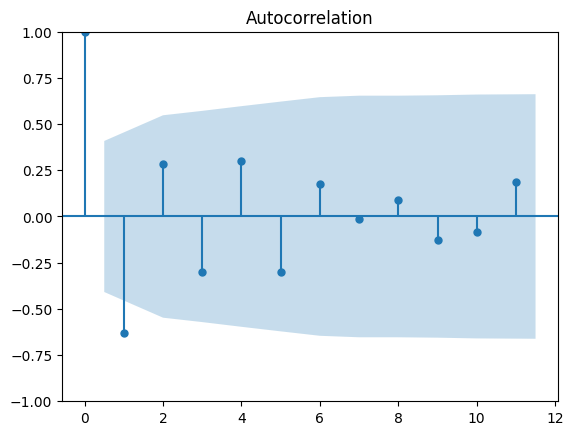

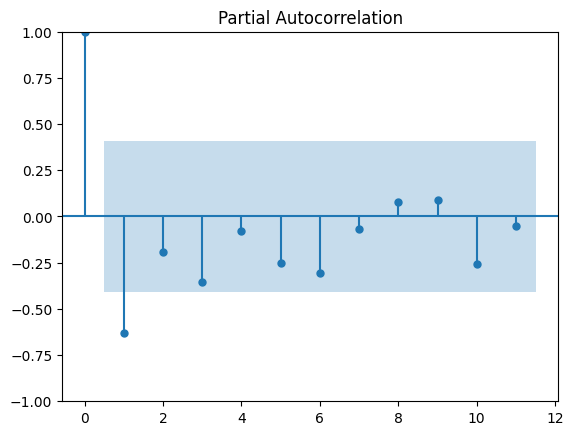

In [6]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

y_values = list(df["SalesAmount"].values)
y_train, y_test = y_values[:-12], y_values[-12:]

x_values = df[["Promotion", "HolidayMonth"]].values
x_train, x_test = x_values[:-12], x_values[-12:]


def diff_calculate(step: int, values: list) -> list:
    result = []
    for i in range(step, len(values)):
        result.append(
            values[i] - values[i-step]
        )
    return result

seasonal_diff = diff_calculate(step=12, values=y_train) # сезонная разность с шагом в 12 месяев 
final_diff = diff_calculate(step=1, values=seasonal_diff) # оставляем шум

plot_acf(final_diff, lags=len(final_diff) // 2)
plot_pacf(final_diff, lags=len(final_diff) // 2)
plt.show()

- По графикам видно, что за доверительную зону выходят значения с x=1 => p=1, q=1, d=1
- Годовая сезонность была подтверждена на этапе EDA (s=12)

/Users/superuser/mai/mai_2/2/analitics/lr1/myenv/lib/python3.14/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


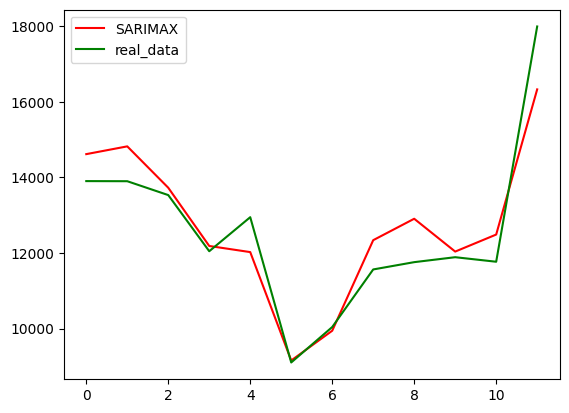

                                      SARIMAX Results                                      
Dep. Variable:                                   y   No. Observations:                   36
Model:             SARIMAX(1, 1, 1)x(1, 1, [], 12)   Log Likelihood                -190.499
Date:                             Mon, 27 Apr 2026   AIC                            392.999
Time:                                     02:53:10   BIC                            399.812
Sample:                                          0   HQIC                           394.712
                                              - 36                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1          2586.9360    335.365      7.714      0.000    1929.633    3244.239
x2             0.0005   808

In [7]:
model = SARIMAX(
    y_train,
    exog=x_train,
    order=(1, 1, 1), seasonal_order=(1, 1, 0, 12),
    # order=(1, 1, 0), seasonal_order=(1, 1, 0, 12)
)
res = model.fit()
y_pred = res.forecast(steps=12, exog=x_test)

plt.plot(y_pred, color="r", label="SARIMAX")
plt.plot(y_test, color="g", label="real_data")
plt.legend()
plt.show()

print(res.summary())

- В результате обучения, модел показала, что HolidayMonth не обладает реальной значимостью (P > 0.05)
- Попробовал сравнить MA и AR, хоть графики и стали внешне в большей степени схожи, но статичтика показала несерьезное улучшение 
- Основная пробема, слишком мало данных для данного кол-ва параметров
- Решено оставить только Promotion

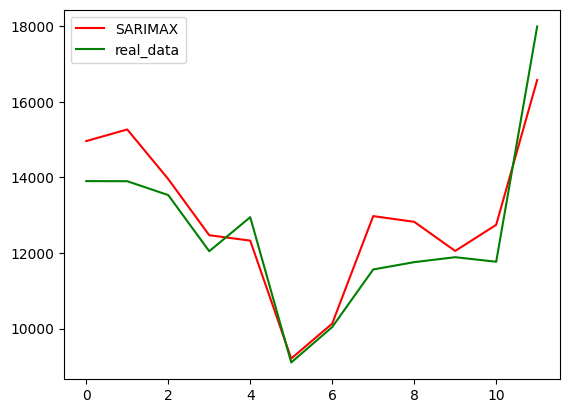

                                      SARIMAX Results                                      
Dep. Variable:                                   y   No. Observations:                   36
Model:             SARIMAX(0, 1, 1)x(0, 1, [], 12)   Log Likelihood                -193.695
Date:                             Mon, 27 Apr 2026   AIC                            393.390
Time:                                     02:53:10   BIC                            396.797
Sample:                                          0   HQIC                           394.247
                                              - 36                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1          2594.4555    291.303      8.906      0.000    2023.512    3165.399
ma.L1         -0.1547      

In [8]:
x_prom_train = x_train[:, 0:1]
x_prom_test = x_test[:, 0:1]

model = SARIMAX(
    y_train,
    exog=x_prom_train,
    order=(0, 1, 1), seasonal_order=(0, 1, 0, 12)
    # order=(1, 1, 1), seasonal_order=(1, 1, 0, 12),
    # order=(1, 1, 0), seasonal_order=(1, 1, 0, 12)
)
res1 = model.fit()
y_pred_sarimax = res1.forecast(steps=12, exog=x_prom_test)

plt.plot(y_pred_sarimax, color="r", label="SARIMAX")
plt.plot(y_test, color="g", label="real_data")
plt.legend()
plt.show()

print(res1.summary())

- Первичный анализ с параметрами прошлой модели показал снижение AIC до 391
- "ar.S.L12 -0.3027 0.166 -1.820 0.069" - видно приближение к значимости, чего нельзя сказать о другим метриках
- Решено попробовать без AR и MA 
- После пошагового упрощения модели были установлены следующие параметры: SARIMAX((0, 1, 1), (0, 1, 0, 12)). Экзоген - "Promotion"

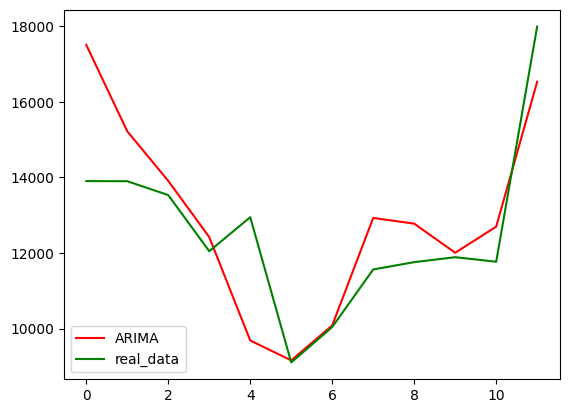

                                     SARIMAX Results                                     
Dep. Variable:                                 y   No. Observations:                   36
Model:             ARIMA(0, 1, 1)x(0, 1, [], 12)   Log Likelihood                -209.867
Date:                           Mon, 27 Apr 2026   AIC                            423.734
Time:                                   02:53:10   BIC                            426.005
Sample:                                        0   HQIC                           424.305
                                            - 36                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.3182      0.112     -2.850      0.004      -0.537      -0.099
sigma2      4.637e+06   1.51e+06      3.068

In [9]:
from statsmodels.tsa.arima.model import ARIMA 

model = ARIMA(
    y_train,
    order=(0, 1, 1),
    seasonal_order=(0, 1, 0, 12)
)
res2 = model.fit()
y_pred_arima = res2.forecast(steps=12)

plt.plot(y_pred_arima, color="r", label="ARIMA")
plt.plot(y_test, color="g", label="real_data")
plt.legend()
plt.show()

print(res2.summary())

- В отсуствие "Promotion", на первое место выходит MA-лаг, из-за чего значимость этого параметра куда выше, в отличие от прошлой модели 
- AIC заметно меньше (424), что говорит нам о большой значимости экзогена "Promotion"

**№2.3**

Пункт 1

In [10]:
from sklearn.metrics import mean_squared_error, r2_score 

mse_sarimax = mean_squared_error(y_pred=y_pred_sarimax, y_true=y_test)
mse_arima = mean_squared_error(y_pred=y_pred_arima, y_true=y_test)
print("---mean_squared_error---")
print(f"mse_sarimax = {mse_sarimax}, sqrt_mse_sarimax = {np.sqrt(mse_sarimax)}")
print(f"mse_arima = {mse_arima}, sqrt_mse_arima = {np.sqrt(mse_arima)}")
print()
print("---r2_score---")
r2_sarimax = r2_score(y_true=y_test, y_pred=y_pred_sarimax)
r2_arima = r2_score(y_true=y_test, y_pred=y_pred_arima)
print(f"r2_score_sarimax = {r2_sarimax}")
print(f"r2_score_arima = {r2_arima}")


---mean_squared_error---
mse_sarimax = 823231.1421063904, sqrt_mse_sarimax = 907.3208595124387
mse_arima = 2632736.109455462, sqrt_mse_arima = 1622.5708334169767

---r2_score---
r2_score_sarimax = 0.8219984548320932
r2_score_arima = 0.43074177890873333


- Видим результаты 
- Очевидно, что модель SARIMAX для текущего датасета предпочтительнее
- r2_score_sarimax = 82% - это впечатляющий результат, r2_score_arima показал, что модель плохо справляется 
- Размер ошибки также выгодно отличается в сторону SARIMAX

Пункт 2

In [11]:
# Значение уже были получены ранее
aic_sarimax = res1.aic 
aic_arima = res2.aic
print("---aic---")
print(f"aic_sarimax = {aic_sarimax}")
print(f"aic_arima = {aic_arima}")
print()
print("---bic---")
bic_sarimax = res1.bic
bic_arima = res2.bic
print(f"bic_sarimax = {bic_sarimax}")
print(f"bic_arima = {bic_arima}")

---aic---
aic_sarimax = 393.3902234178206
aic_arima = 423.7340816833767

---bic---
bic_sarimax = 396.7967060656081
bic_arima = 426.005070115235


Пункт 3

In [12]:
# Получаем остатки
resid_sarimax = res1.resid
resid_arima = res2.resid

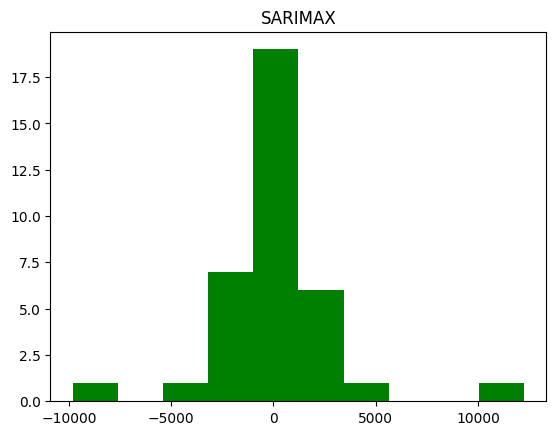

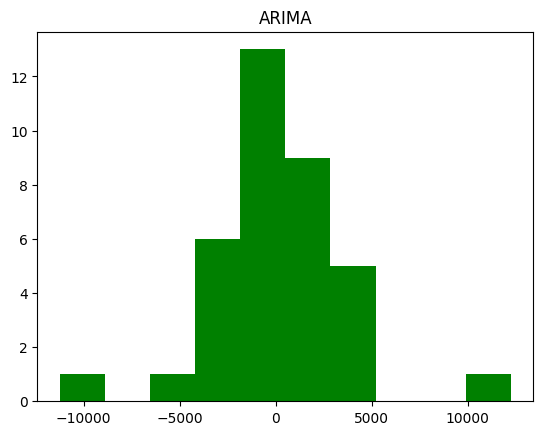

In [13]:
# Проверяем на нормальность
plt.hist(resid_sarimax, color="g", bins=10)
plt.title("SARIMAX")
plt.show()
plt.hist(resid_arima, color="g", bins=10, label="ARIMA")
plt.title("ARIMA")
plt.show()

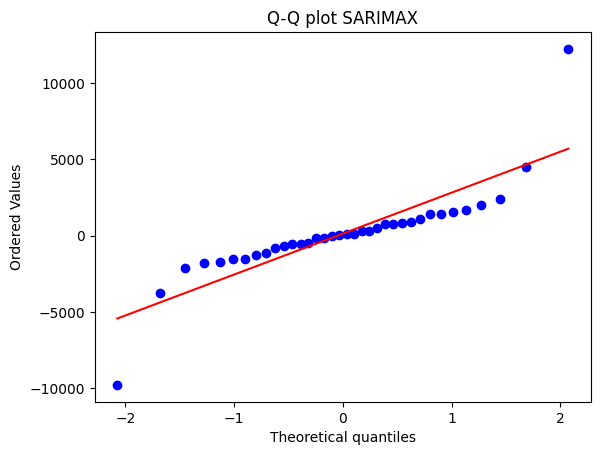

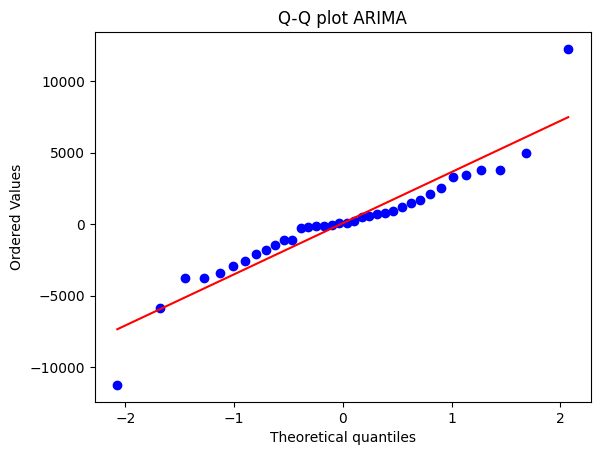

In [14]:
from scipy import stats

stats.probplot(resid_sarimax, dist="norm", plot=plt)
plt.title('Q-Q plot SARIMAX')
plt.show()
stats.probplot(resid_arima, dist="norm", plot=plt)
plt.title('Q-Q plot ARIMA')
plt.show()

- В целом данные распределны нормально
- Однако на q-q графике видны выбросы, которые, скорее всего, связаны с маленьким размером датасета и с резкими сезонными скачками
- На обоих графиках нормальность остатков выглядит приемлемо, учитывая упомянутые выше ограничения, на SARIMAX выглядит лучше

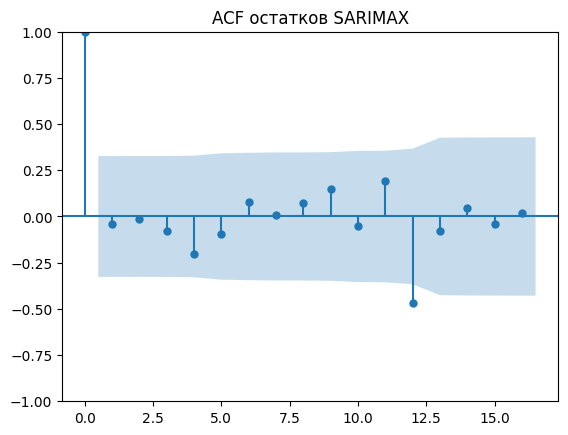

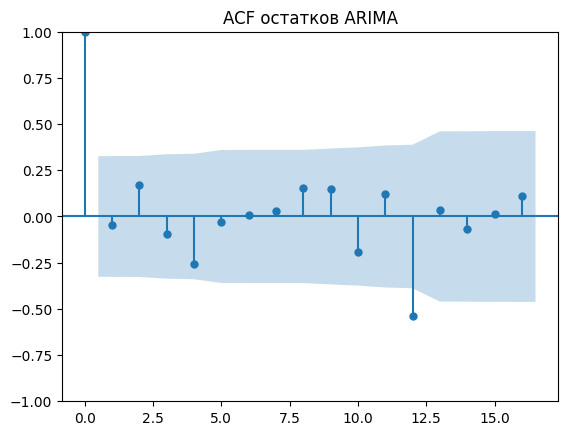

In [15]:
# Автокоррелированность
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(resid_sarimax)
plt.title("ACF остатков SARIMAX")
plt.show()
plot_acf(resid_arima)
plt.title("ACF остатков ARIMA")
plt.show()

- Примерно на лаге 12 наблюдается выброс
- Это может говорить нам о том, что модель не полностью устранила годовой паттерн
- Полностью преодалеть данную проблему не удается 

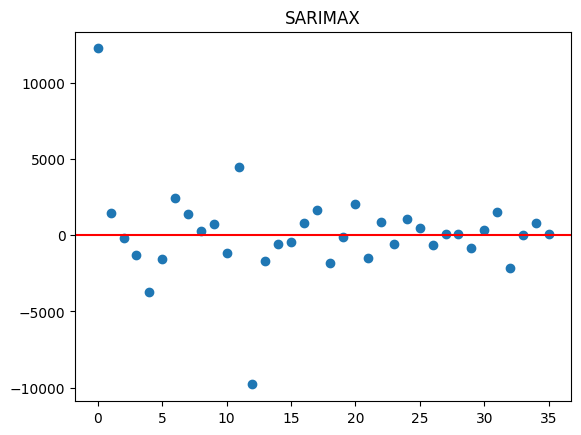

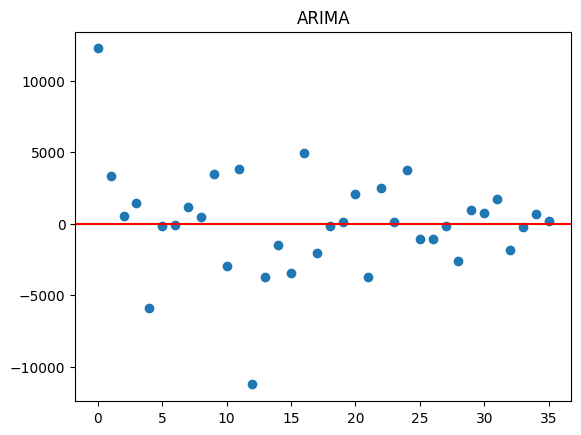

In [16]:
# Гомоскедастичность
plt.scatter(range(len(resid_sarimax)), resid_sarimax)
plt.axhline(y=0, color="r")
plt.title("SARIMAX")
plt.show()

plt.scatter(range(len(resid_arima)), resid_arima)
plt.axhline(y=0, color="r")
plt.title("ARIMA")
plt.show()

- Разброс на первом графике выглядит более структурированно, есть пару выбросов
- Картина на втором графике куда более неоднородная - признак гетероскедастичности

Пункт 3

In [17]:
# Результирующая таблица, графики изображены выше 
sqrt_mse_sarimax = np.sqrt(mse_sarimax)
sqrt_mse_arima = np.sqrt(mse_arima)

result_table = {
    "VALUES": ["MSE", "SQRT_MSE", "AIC", "BIC"],
    "SARIMAX": [mse_sarimax, sqrt_mse_sarimax, aic_sarimax, bic_sarimax],
    "ARIMA": [mse_arima, sqrt_mse_arima, aic_arima, bic_arima]
}
result_table = pd.DataFrame(result_table)

pd.set_option('display.float_format', '{:.2f}'.format)
print(result_table)

     VALUES   SARIMAX      ARIMA
0       MSE 823231.14 2632736.11
1  SQRT_MSE    907.32    1622.57
2       AIC    393.39     423.73
3       BIC    396.80     426.01


- В результате проведенной работы было рассмотрено две модели: SARIMAX и ARIMA
- Наиболее предпочтительной оказалась SARIMAX, по всем метрикам обошедшая ARIMA
- Учитывая ограничения датасета, модель SARIMAX показала хороший результат

In [18]:
!rm -rf myenv